In [ ]:
#@title 📦 Install ComfyUI Server and Dependencies
#@markdown This cell initializes the environment, clones the repository, and sets up all required libraries.

import os, torch, gc, time, json, uuid, urllib.request, datetime, subprocess, re, sys, hashlib
from IPython.display import display, Image, Audio, clear_output
import numpy as np
from tqdm.notebook import tqdm

def check_disk_space():
    """Checks and prints available disk space."""
    s = os.statvfs('/')
    free = (s.f_bavail * s.f_frsize) / (1024**3)
    print(f"💾 Available Disk Space: {free:.2f} GB")
    if free < 7:
        print("⚠️ Warning: Very low disk space! SDXL models require ~7GB free just to download.")
        print("💡 Solution: Go to 'Runtime' -> 'Disconnect and delete runtime' to start with a fresh disk.")

def setup_comfy_environment():
    """Installs ComfyUI and basic dependencies."""
    check_disk_space()
    os.chdir("/content/")
    if not os.path.exists("/content/ComfyUI"):
        print("📦 Installing ComfyUI core...")
        subprocess.run(["git", "clone", "https://github.com/comfyanonymous/ComfyUI"], check=True)
        os.chdir("/content/ComfyUI")
        subprocess.run(["pip", "install", "-r", "requirements.txt"], check=True)
        print("📦 Installing aria2...")
        subprocess.run(["apt", "-y", "install", "aria2"], check=True)
    else:
        print("✅ ComfyUI already installed.")
        os.chdir("/content/ComfyUI")

def download_resource(url, token, dest_dir):
    """Helper to download models using aria2."""
    if not os.path.exists(dest_dir): os.makedirs(dest_dir)

    def _get_unique_name(u):
        return "file_" + hashlib.md5(u.encode()).hexdigest()[:8] + ".safetensors"

    filename = _get_unique_name(url)
    try:
        req_headers = {'User-Agent': 'Mozilla/5.0'}
        if token: req_headers['Authorization'] = f'Bearer {token}'
        req = urllib.request.Request(url, headers=req_headers)
        with urllib.request.urlopen(req) as response:
            cd = response.info().get('Content-Disposition')
            if cd:
                fname_match = re.findall("filename\\*?=['\"]?(?:UTF-8'')?([^;\"']+)['\"]?", cd)
                if fname_match: filename = urllib.parse.unquote(fname_match[0])
    except: pass

    filename = filename.split('/')[-1]
    if not any(filename.lower().endswith(ext) for ext in ['.safetensors', '.ckpt', '.pt']):
        filename += ".safetensors"

    dest_path = os.path.join(dest_dir, filename)
    if not os.path.exists(dest_path):
        print(f"📥 Downloading: {filename}...")
        download_url = url
        if token and "token=" not in url:
            sep = "&" if "?" in url else "?"
            download_url += f"{sep}token={token}"
        cmd = f'aria2c --console-log-level=info -c -x 16 -s 16 -k 1M "{download_url}" -d "{dest_dir}" -o "{filename}"'
        subprocess.run(cmd, shell=True, check=True)
    else:
        print(f"✅ {filename} already exists.")
    return filename

def start_comfy_server():
    """Launches the ComfyUI backend."""
    subprocess.run(["fuser", "-k", "8188/tcp"], capture_output=True)
    time.sleep(2)
    print("🚀 Starting ComfyUI Server...")
    os.chdir("/content/ComfyUI")
    proc = subprocess.Popen(
        ["python", "main.py", "--port", "8188", "--listen", "127.0.0.1", "--lowvram", "--fp16-vae"],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
    )
    for _ in range(30):
        try:
            urllib.request.urlopen("http://127.0.0.1:8188/history").read()
            return proc
        except: time.sleep(5)
    raise TimeoutError("Server failed to start.")

In [ ]:
#@title ⚙️ Configuration
#@markdown Configure your generation settings below.

# --- Model Links ---
Checkpoint_model_url = "https://huggingface.co/LyliaEngine/Pony_Diffusion_V6_XL/resolve/main/ponyDiffusionV6XL_v6StartWithThisOne.safetensors?download=true" #@param {type:"string"}
lora_model_url = "None" #@param {type:"string"}
Add_checkpoint_model_token = "" #@param {type:"string"}

# --- Prompts ---
user_prompt = "score_9, score_8_up, score_7_up, score_6_up, score_5_up, score_4_up, source_furry, beautiful female anthro shark portrait, dramatic lighting, dark background" #@param {type:"string"}
negative_prompt = "low quality, bad anatomy, distorted face, blurry, text, watermark" #@param {type:"string"}

# --- Image Dimensions ---
width = 768 #@param {type:"slider", min:256, max:2048, step:64}
height = 1024 #@param {type:"slider", min:256, max:2048, step:64}

# --- Sampling Parameters ---
steps = 30 #@param {type:"integer"}
cfg = 8 #@param {type:"slider", min:1, max:20, step:0.5}
lora_strength_model = 0 #@param {type:"slider", min:0, max:2, step:0.05}

sampler = "euler" #@param ["euler", "euler_ancestral", "heun", "heunpp2", "dpm_2", "dpm_2_ancestral", "lms", "dpmpp_2s_ancestral", "dpmpp_sde", "dpmpp_sde_gpu", "dpmpp_2m", "dpmpp_2m_sde", "dpmpp_2m_sde_gpu", "dpmpp_3m_sde", "dpmpp_3m_sde_gpu", "ddim", "uni_pc", "uni_pc_bh2"]
scheduler = "simple" #@param ["normal", "karras", "exponential", "sgm_uniform", "simple", "ddim_uniform"]

💾 Available Disk Space: 57.73 GB
✅ ComfyUI already installed.
⌛ Loading main model...
📥 Downloading: ponyDiffusionV6XL_v6StartWithThisOne.safetensors...
ℹ️ No LoRA provided. Generating direct text-to-image.
✨ Generating with Model: ponyDiffusionV6XL_v6StartWithThisOne.safetensors (LoRA: None)


🎨 Generating:   0%|          | 0/30 [00:00<?, ?step/s]

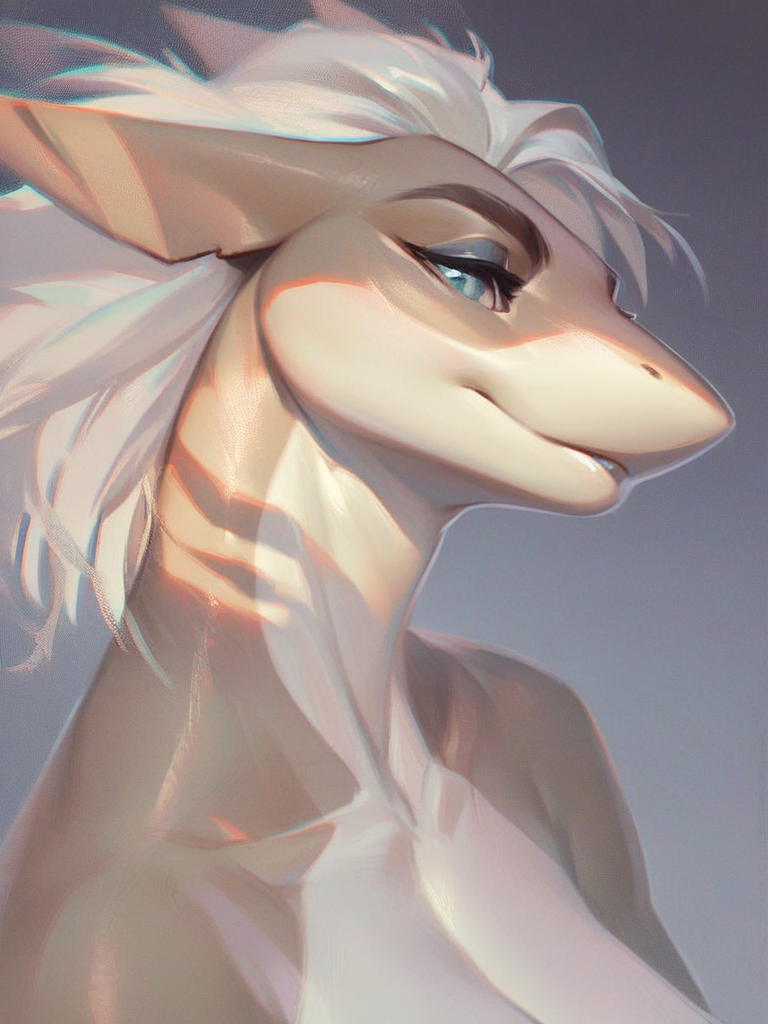

True

In [ ]:
#@title 🚀 Run Generation
#@markdown ### ℹ️ Generation Information
#@markdown * **First Run:** Typically takes **1-2 minutes** as the system initializes the ComfyUI server and loads the model into VRAM.
#@markdown * **Subsequent Runs:** Usually takes **less than 1 minute** since the models remain cached in memory.

# ==========================================
# 3. EXECUTION
# ==========================================

# Init Environment and Handle Downloads
try:
    setup_comfy_environment()
    print("⌛ Loading main model...")
    ckpt_name = download_resource(main_model_url, main_model_token, "/content/ComfyUI/models/checkpoints")

    # Dynamic LoRA Detection
    use_lora = False
    lora_name = None
    if lora_model_url and lora_model_url.lower() != "none" and lora_model_url.strip() != "":
        print("⌛ Loading LoRA model...")
        lora_name = download_resource(lora_model_url, main_model_token, "/content/ComfyUI/models/loras")
        use_lora = True
    else:
        print("ℹ️ No LoRA provided. Generating direct text-to-image.")

except Exception as e:
    print(f"❌ Download Error: {e}")
    raise

# Start Server
if 'comfy_proc' not in globals() or globals()['comfy_proc'].poll() is not None:
    globals()['comfy_proc'] = start_comfy_server()

# Build Dynamic Workflow
actual_seed = np.random.randint(0, 1000000000)
workflow = {
    "1": {"inputs": {"ckpt_name": ckpt_name}, "class_type": "CheckpointLoaderSimple"},
    "5": {"inputs": {"width": width, "height": height, "batch_size": 1}, "class_type": "EmptyLatentImage"},
    "7": {"inputs": {"samples": ["6", 0], "vae": ["1", 2]}, "class_type": "VAEDecode"},
    "8": {"inputs": {"images": ["7", 0], "filename_prefix": "Output"}, "class_type": "SaveImage"}
}

if use_lora:
    workflow["2"] = {
        "inputs": {
            "lora_name": lora_name,
            "strength_model": lora_strength_model,
            "strength_clip": 1.0,
            "model": ["1", 0], "clip": ["1", 1]
        },
        "class_type": "LoraLoader"
    }
    workflow["3"] = {"inputs": {"text": user_prompt, "clip": ["2", 1]}, "class_type": "CLIPTextEncode"}
    workflow["4"] = {"inputs": {"text": negative_prompt, "clip": ["2", 1]}, "class_type": "CLIPTextEncode"}
    workflow["6"] = {
        "inputs": {
            "seed": actual_seed, "steps": steps, "cfg": cfg,
            "sampler_name": sampler, "scheduler": scheduler, "denoise": 1.0,
            "model": ["2", 0],
            "positive": ["3", 0], "negative": ["4", 0], "latent_image": ["5", 0]
        },
        "class_type": "KSampler"
    }
else:
    workflow["3"] = {"inputs": {"text": user_prompt, "clip": ["1", 1]}, "class_type": "CLIPTextEncode"}
    workflow["4"] = {"inputs": {"text": negative_prompt, "clip": ["1", 1]}, "class_type": "CLIPTextEncode"}
    workflow["6"] = {
        "inputs": {
            "seed": actual_seed, "steps": steps, "cfg": cfg,
            "sampler_name": sampler, "scheduler": scheduler, "denoise": 1.0,
            "model": ["1", 0],
            "positive": ["3", 0], "negative": ["4", 0], "latent_image": ["5", 0]
        },
        "class_type": "KSampler"
    }

def run_inference(workflow_json):
    data = json.dumps({"prompt": workflow_json, "client_id": str(uuid.uuid4())}).encode('utf-8')
    try:
        req = urllib.request.Request("http://127.0.0.1:8188/prompt", data=data)
        response = json.loads(urllib.request.urlopen(req).read())
        prompt_id = response['prompt_id']
        with tqdm(total=steps, desc=f"🎨 Generating", unit="step") as pbar:
            while True:
                try:
                    h = json.loads(urllib.request.urlopen(f"http://127.0.0.1:8188/history/{prompt_id}").read())
                    if prompt_id in h:
                        out = h[prompt_id].get('outputs', {})
                        if '8' in out:
                            fn = out['8']['images'][0]['filename']
                            with urllib.request.urlopen(f"http://127.0.0.1:8188/view?filename={fn}&type=output") as img:
                                display(Image(data=img.read()))
                            pbar.n = steps
                            pbar.refresh()
                            return True
                except: pass
                time.sleep(2)
    except Exception as e: print(f"❌ Inference Error: {e}"); return False

print(f"✨ Generating with Model: {ckpt_name} (LoRA: {lora_name if use_lora else 'None'})")
run_inference(workflow)